In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# Model:

In [2]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Data

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


# Training the model

In [4]:
device="cuda"
epochs=3
model=SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [7]:
for epoch in tqdm(range(epochs)):
    for images, targets in trainloader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

100%|██████████| 3/3 [00:51<00:00, 17.14s/it]


# Calculating entropy (uncertainety score) of all inputs after training data before the attack:

In [8]:
def get_entropy(logits):
    probs = torch.nn.functional.softmax(logits.detach(), dim=1)
    return -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean().detach()

In [9]:
before_entropies=[]
for image,label in tqdm(trainset):
  before_entropies.append(get_entropy(model(image.cuda())))

100%|██████████| 60000/60000 [00:36<00:00, 1636.00it/s]


## Pick a random sample from training set:

In [24]:
index_of_sample=random.randint(0,len(trainset)-1)

In [25]:
before_entropy=before_entropies[index_of_sample]
before_entropy.item()

0.0066444156691432

## Check the rank of this sample before attack:

In [26]:
for index,i in enumerate(sorted(before_entropies)):
  if i.item()==before_entropy.item():
    print(60000-index)

48607


# Attack on the selected sample

In [27]:
x_original=trainset[index_of_sample][0].cuda()

In [28]:
model.eval()

SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [29]:
def entropy_attack(model, x, epsilon=0.3, alpha=0.01, iters=100):
    x_adv = x.clone().detach().requires_grad_(True)

    for _ in tqdm(range(iters)):
        logits = model(x_adv)
        probs = F.softmax(logits, dim=1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()  # Compute entropy

        # Compute gradient
        entropy.backward()
        grad = x_adv.grad.data

        # Perform PGD step
        x_adv = x_adv + alpha * grad.sign()

        # Project back into the epsilon-ball
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)
        x_adv = torch.clamp(x_adv, 0, 1)  # Ensure valid pixel range [0,1]

        # Detach and re-enable gradient tracking for next step
        x_adv = x_adv.detach().requires_grad_(True)

    return x_adv.detach()

In [30]:
x_adv=entropy_attack(model,x_original)

100%|██████████| 100/100 [00:00<00:00, 433.45it/s]


## Entropy of the original sample:

In [31]:
get_entropy(model(x_original)).item()

0.0066444156691432

## Entropy of the adversarial sample achieved by PGD:

In [32]:
get_entropy(model(x_adv)).item()

1.882748007774353

## Visualizing the original adn adversarial image:

In [33]:
def show_images(original, adversarial):
    original = original.squeeze().cpu().detach().numpy()
    adversarial = adversarial.squeeze().cpu().detach().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[1].imshow(adversarial)
    axes[1].set_title("Adversarial Image")
    plt.show()

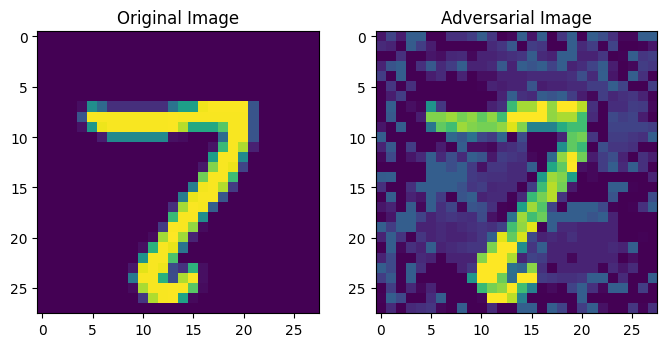

In [34]:
show_images(x_original,x_adv)

# Now let's put the adversarial image X_adv in to the training set by replacing it with the original sample:

In [35]:
trainset.data[index_of_sample]=(x_adv.squeeze()*255).to(torch.uint8).detach().cpu()
trainloader2 = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

## Now we train the model with the poisoned dataset containing our X_adv:

In [36]:
epochs=3
model=SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [37]:
for epoch in tqdm(range(epochs)):
    for images, targets in trainloader2:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

100%|██████████| 3/3 [00:55<00:00, 18.56s/it]


# Calculating entropy (uncertainety score) of all inputs after training data after the attack (putting X_adv into the training pool):

In [38]:
after_entropies=[]
for image,label in tqdm(trainset):
  after_entropies.append(get_entropy(model(image.cuda())))

100%|██████████| 60000/60000 [00:37<00:00, 1605.09it/s]


## Entropy of the X_adv

In [39]:
after_entropy=after_entropies[index_of_sample]
after_entropy.item()

1.1482435464859009

## Check the rank of the X_adv

In [40]:
for index,i in enumerate(sorted(after_entropies)):
  if i.item()==after_entropy.item():
    print()
    print(60000-index)


1003


## So we managed to manipulate a random and arbitrary sample from the training set so that the rank of the uncertainety score of this sample among all training set went from 48607 before our attack to the 1003-th data after our attack. This means we increased the chance of this random sample to be selected by the uncertainety selection method if they were going to select for example 1500 samples or more from all the 60,000 samples.

## Hyperparameters that we can control:


*   Number of epochs
*   Model architecture
*   The amount of perturbation allowed in PGD (epsilon)






# In this notebook, we assumed that the victim company will exactly train 3 epochs and use the same model as what attacker assumes they will train. We will then explore the transferability of our attack (attacker and victim company might use different models and different number of epochs) and in part2 we will try the bilevel optimization which is much stronger (read the proposal for more details about the rationale)